# Chapter 9.5: Incremental & Online Training

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Implement** streaming SGD and mini-batch online learning for real-time model updates
2. **Build** concept drift detectors using PSI (Population Stability Index) and KL divergence
3. **Design** staleness management policies balancing freshness vs stability
4. **Compare** warm-starting vs cold-starting strategies for model retraining
5. **Evaluate** online vs batch-retrained models with A/B testing frameworks
6. **Construct** a complete incremental learning pipeline with drift detection
7. **Monitor** model performance degradation over time and trigger retraining

## Prerequisites

- Understanding of SGD and mini-batch training
- Familiarity with recommendation model evaluation
- Basic statistics (KL divergence, hypothesis testing)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.5_incremental_training.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.5_incremental_training.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import copy
from typing import List, Dict, Tuple, Optional
from collections import defaultdict, deque

np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

All imports successful!
PyTorch version: 2.2.2


## 1. Why Online/Incremental Training?

Recommendation systems operate in a **non-stationary** environment:

- **User preferences shift** (seasonal trends, current events)
- **New items arrive** continuously (cold start)
- **Item relevance decays** (news articles, trending products)
- **User base evolves** (new users, changing demographics)

### Batch vs Online Training

| Aspect | Batch Retraining | Online/Incremental |
|--------|-----------------|--------------------|
| **Freshness** | Hours to days old | Minutes to real-time |
| **Cost** | Full training run each time | Marginal cost per update |
| **Stability** | Very stable | Risk of catastrophic forgetting |
| **Cold Start** | Slow for new items | New items trained immediately |
| **Infrastructure** | Simpler | Requires streaming infrastructure |

Production practice at major companies:
- **Meta**: Models update every few hours with warm-start
- **Google (YouTube)**: Real-time updates for the retrieval tower
- **ByteDance (TikTok)**: Near-real-time updates (~minutes)
- **LinkedIn**: Hourly incremental training with daily full retraining

> **💡 Concept:** The optimal strategy is usually **hybrid**: online incremental updates for fast adaptation with periodic full retraining ("big model" refresh) to correct accumulated drift and errors.

In [2]:
# Simulate a non-stationary recommendation environment

class NonStationaryEnvironment:
    """Simulates a recommendation environment with concept drift."""
    
    def __init__(self, num_users: int = 2000, num_items: int = 5000,
                 embedding_dim: int = 16, drift_rate: float = 0.01):
        self.num_users = num_users
        self.num_items = num_items
        self.drift_rate = drift_rate
        self.time_step = 0
        
        # True user/item representations (hidden from the model)
        self.user_factors = np.random.randn(num_users, embedding_dim) * 0.1
        self.item_factors = np.random.randn(num_items, embedding_dim) * 0.1
        
        # Item popularity (changes over time)
        self.item_popularity = np.random.zipf(1.5, num_items).astype(np.float64)
        self.item_popularity = np.clip(self.item_popularity, 1, 500)
        self.item_popularity /= self.item_popularity.sum()
    
    def step(self):
        """Advance time by one step, applying drift."""
        self.time_step += 1
        
        # Gradual drift in user preferences
        self.user_factors += np.random.randn(*self.user_factors.shape) * self.drift_rate
        
        # Gradual drift in item characteristics
        self.item_factors += np.random.randn(*self.item_factors.shape) * self.drift_rate * 0.5
        
        # Occasional sudden shifts (e.g., trending topics)
        if self.time_step % 100 == 0:
            # Sudden popularity shift: random items become trending
            trending = np.random.choice(self.num_items, 50, replace=False)
            self.item_popularity[trending] *= 5
            self.item_popularity /= self.item_popularity.sum()
    
    def generate_batch(self, batch_size: int) -> Dict:
        """Generate a batch of interactions based on current state."""
        users = np.random.randint(0, self.num_users, batch_size)
        items = np.random.choice(self.num_items, batch_size, p=self.item_popularity)
        
        # Click probability based on user-item affinity
        scores = np.sum(self.user_factors[users] * self.item_factors[items], axis=1)
        click_probs = 1 / (1 + np.exp(-scores))
        labels = (np.random.random(batch_size) < click_probs).astype(np.float32)
        
        return {
            'users': torch.tensor(users, dtype=torch.long),
            'items': torch.tensor(items, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.float32),
            'time_step': self.time_step
        }


env = NonStationaryEnvironment(drift_rate=0.02)

# Show how the environment changes over time
ctr_over_time = []
pop_entropy_over_time = []

for t in range(500):
    env.step()
    batch = env.generate_batch(1000)
    ctr = batch['labels'].mean().item()
    ctr_over_time.append(ctr)
    
    # Popularity entropy (lower = more concentrated)
    entropy = -np.sum(env.item_popularity * np.log(env.item_popularity + 1e-10))
    pop_entropy_over_time.append(entropy)

print(f"Time steps: {env.time_step}")
print(f"Average CTR: {np.mean(ctr_over_time):.4f}")
print(f"CTR std: {np.std(ctr_over_time):.4f}")

Time steps: 500
Average CTR: 0.5004
CTR std: 0.0157


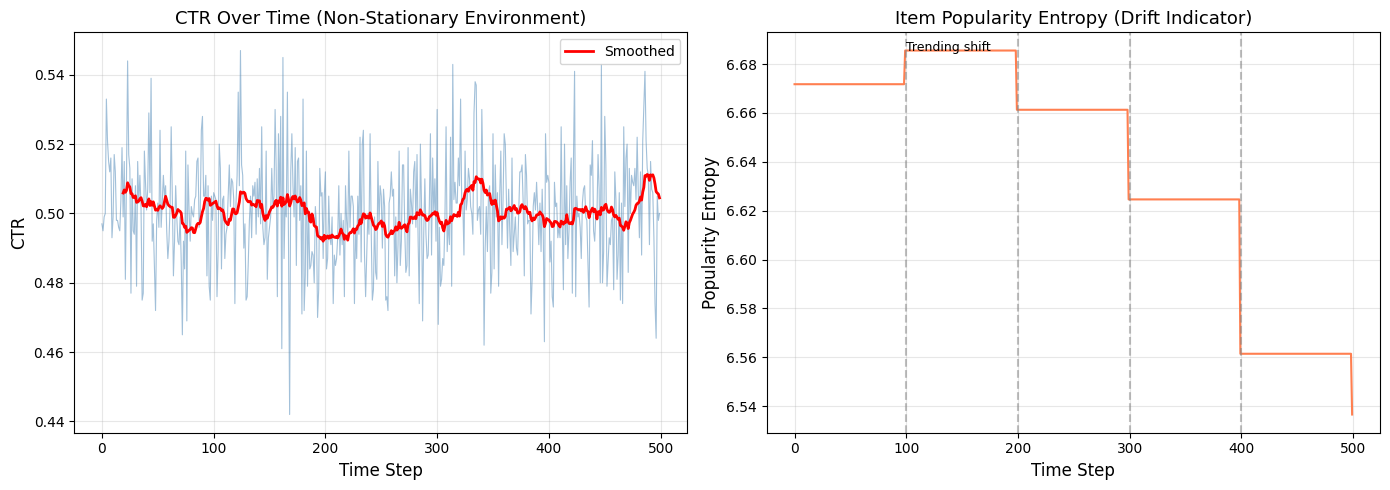

In [3]:
# Visualize environment drift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ctr_over_time, alpha=0.5, color='steelblue', linewidth=0.8)
window = 20
smoothed_ctr = np.convolve(ctr_over_time, np.ones(window)/window, mode='valid')
axes[0].plot(range(window-1, len(ctr_over_time)), smoothed_ctr, color='red', linewidth=2, label='Smoothed')
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('CTR', fontsize=12)
axes[0].set_title('CTR Over Time (Non-Stationary Environment)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(pop_entropy_over_time, color='coral', linewidth=1.5)
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('Popularity Entropy', fontsize=12)
axes[1].set_title('Item Popularity Entropy (Drift Indicator)', fontsize=13)
axes[1].grid(True, alpha=0.3)
# Mark sudden shifts
for t in range(100, 500, 100):
    axes[1].axvline(x=t, color='gray', linestyle='--', alpha=0.5)
axes[1].annotate('Trending shift', xy=(100, pop_entropy_over_time[100]), fontsize=9)

plt.tight_layout()
plt.show()

## 2. Streaming SGD and Mini-Batch Online Learning

Online learning processes data as it arrives, updating the model with each batch:

$$\theta_{t+1} = \theta_t - \eta_t \nabla_{\theta} \mathcal{L}(x_t, y_t; \theta_t)$$

Key considerations:
- **Learning rate**: Too high causes instability; too low fails to adapt
- **Regularization**: Essential to prevent overfitting on recent data
- **EWC (Elastic Weight Consolidation)**: Prevents catastrophic forgetting of old patterns

$$\mathcal{L}_{\text{EWC}} = \mathcal{L}(\theta) + \frac{\lambda}{2} \sum_i F_i (\theta_i - \theta^*_i)^2$$

where $F_i$ is the Fisher information for parameter $i$ and $\theta^*$ are the old parameters.

In [4]:
class SimpleRecModel(nn.Module):
    """Simple recommendation model for online learning experiments."""
    def __init__(self, num_users, num_items, emb_dim=16):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def forward(self, users, items):
        u = self.user_emb(users)
        v = self.item_emb(items)
        x = torch.cat([u, v], dim=1)
        return self.mlp(x).squeeze()


class OnlineTrainer:
    """Online learning trainer with optional EWC regularization."""
    
    def __init__(self, model: nn.Module, lr: float = 0.001, 
                 ewc_lambda: float = 0.0, ewc_update_interval: int = 100):
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.ewc_lambda = ewc_lambda
        self.ewc_update_interval = ewc_update_interval
        
        # EWC state
        self.fisher = {}
        self.old_params = {}
        self.step_count = 0
    
    def _compute_fisher(self, data_batches: List[Dict]):
        """Estimate Fisher information matrix (diagonal approximation)."""
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters()}
        
        self.model.eval()
        for batch in data_batches:
            self.model.zero_grad()
            logits = self.model(batch['users'], batch['items'])
            loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
            loss.backward()
            
            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.data.pow(2)
        
        for n in fisher:
            fisher[n] /= len(data_batches)
        
        self.model.train()
        return fisher
    
    def update_ewc(self, recent_batches: List[Dict]):
        """Update EWC anchor point."""
        self.fisher = self._compute_fisher(recent_batches)
        self.old_params = {n: p.data.clone() for n, p in self.model.named_parameters()}
    
    def ewc_penalty(self) -> torch.Tensor:
        """Compute EWC regularization penalty."""
        penalty = torch.tensor(0.0)
        for n, p in self.model.named_parameters():
            if n in self.fisher:
                penalty += (self.fisher[n] * (p - self.old_params[n]).pow(2)).sum()
        return penalty
    
    def train_step(self, batch: Dict) -> float:
        """Execute one online training step."""
        self.step_count += 1
        self.model.train()
        
        logits = self.model(batch['users'], batch['items'])
        loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
        
        if self.ewc_lambda > 0 and self.fisher:
            loss += self.ewc_lambda * self.ewc_penalty()
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()
        
        return loss.item()
    
    def evaluate(self, batch: Dict) -> Dict:
        """Evaluate model on a batch."""
        self.model.eval()
        with torch.no_grad():
            logits = self.model(batch['users'], batch['items'])
            probs = torch.sigmoid(logits)
            loss = F.binary_cross_entropy_with_logits(logits, batch['labels']).item()
            preds = (probs > 0.5).float()
            accuracy = (preds == batch['labels']).float().mean().item()
        return {'loss': loss, 'accuracy': accuracy}


# Compare: Online (no EWC) vs Online (with EWC) vs No update (stale model)
NUM_USERS = 2000
NUM_ITEMS = 5000

env = NonStationaryEnvironment(num_users=NUM_USERS, num_items=NUM_ITEMS, drift_rate=0.02)

torch.manual_seed(42)
model_online = SimpleRecModel(NUM_USERS, NUM_ITEMS)
trainer_online = OnlineTrainer(model_online, lr=0.001, ewc_lambda=0.0)

torch.manual_seed(42)
model_ewc = SimpleRecModel(NUM_USERS, NUM_ITEMS)
trainer_ewc = OnlineTrainer(model_ewc, lr=0.001, ewc_lambda=0.5)

torch.manual_seed(42)
model_stale = SimpleRecModel(NUM_USERS, NUM_ITEMS)

# Train all models on initial data
print("Initial training (50 steps)...")
for step in range(50):
    env.step()
    batch = env.generate_batch(256)
    trainer_online.train_step(batch)
    trainer_ewc.train_step(batch)
    # Stale model also trains on initial data
    optimizer_stale = torch.optim.Adam(model_stale.parameters(), lr=0.001)
    logits = model_stale(batch['users'], batch['items'])
    loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
    optimizer_stale.zero_grad()
    loss.backward()
    optimizer_stale.step()

# Set EWC anchor
recent = [env.generate_batch(256) for _ in range(10)]
trainer_ewc.update_ewc(recent)

# Continue with drift — stale model stops updating
print("Online training with drift (400 steps)...")
online_accs = []
ewc_accs = []
stale_accs = []

for step in range(400):
    env.step()
    train_batch = env.generate_batch(256)
    eval_batch = env.generate_batch(512)
    
    trainer_online.train_step(train_batch)
    trainer_ewc.train_step(train_batch)
    # Stale model: no updates
    
    if step % 50 == 0:
        trainer_ewc.update_ewc([train_batch])
    
    if step % 10 == 0:
        online_accs.append(trainer_online.evaluate(eval_batch)['accuracy'])
        ewc_accs.append(trainer_ewc.evaluate(eval_batch)['accuracy'])
        model_stale.eval()
        with torch.no_grad():
            logits = model_stale(eval_batch['users'], eval_batch['items'])
            preds = (torch.sigmoid(logits) > 0.5).float()
            stale_accs.append((preds == eval_batch['labels']).float().mean().item())

print(f"Final accuracy — Online: {online_accs[-1]:.4f}, EWC: {ewc_accs[-1]:.4f}, Stale: {stale_accs[-1]:.4f}")

Initial training (50 steps)...


Online training with drift (400 steps)...


Final accuracy — Online: 0.4902, EWC: 0.4961, Stale: 0.5020


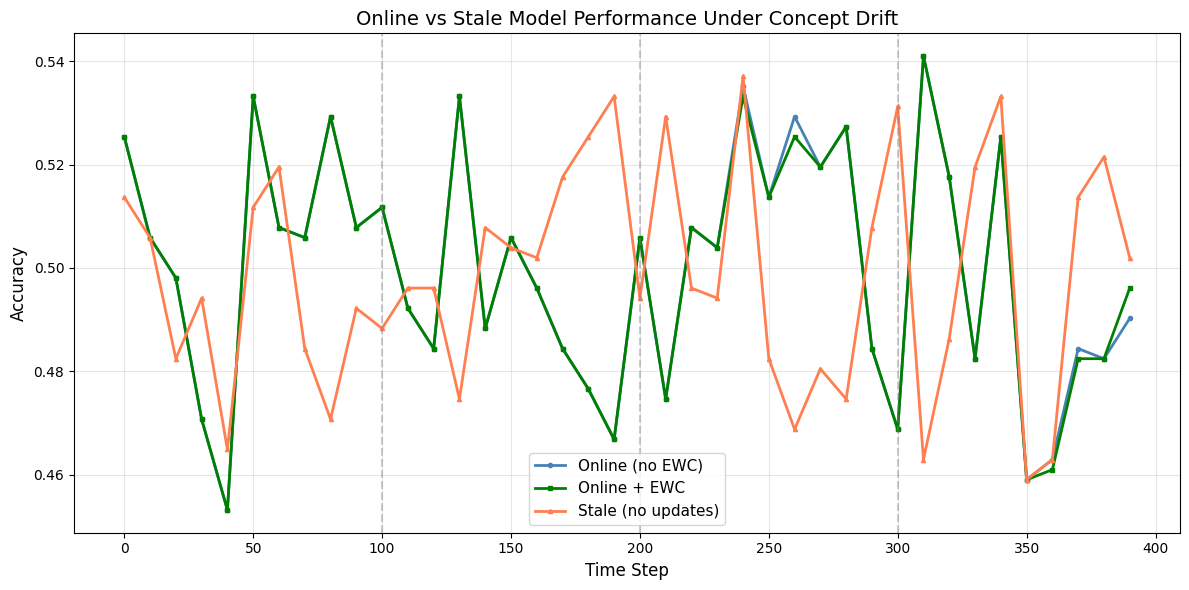

In [5]:
# Visualize online vs stale vs EWC
fig, ax = plt.subplots(figsize=(12, 6))

steps = list(range(0, 400, 10))
ax.plot(steps, online_accs, 'o-', label='Online (no EWC)', color='steelblue', linewidth=2, markersize=3)
ax.plot(steps, ewc_accs, 's-', label='Online + EWC', color='green', linewidth=2, markersize=3)
ax.plot(steps, stale_accs, '^-', label='Stale (no updates)', color='coral', linewidth=2, markersize=3)

ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Online vs Stale Model Performance Under Concept Drift', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Mark drift events
for t in range(100, 400, 100):
    ax.axvline(x=t, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 3. Concept Drift Detection

Detecting when the data distribution has shifted significantly is critical for deciding when to retrain.

### Population Stability Index (PSI)

Compares the distribution of a feature between reference and current data:

$$\text{PSI} = \sum_{i=1}^{B} (p_i^{\text{current}} - p_i^{\text{reference}}) \cdot \ln\frac{p_i^{\text{current}}}{p_i^{\text{reference}}}$$

| PSI Range | Interpretation |
|-----------|---------------|
| < 0.1 | No significant change |
| 0.1 - 0.25 | Moderate change — investigate |
| > 0.25 | Significant change — action required |

### KL Divergence

$$D_{KL}(P \| Q) = \sum_x P(x) \ln \frac{P(x)}{Q(x)}$$

> **⚠️ Common Pitfall:** PSI and KL divergence require binning continuous features. The choice of bins significantly affects the result. Use quantile-based binning rather than equal-width bins for robustness.

In [6]:
class ConceptDriftDetector:
    """Detect concept drift using PSI and KL divergence."""
    
    def __init__(self, num_bins: int = 10, psi_threshold: float = 0.25,
                 kl_threshold: float = 0.5, window_size: int = 1000):
        self.num_bins = num_bins
        self.psi_threshold = psi_threshold
        self.kl_threshold = kl_threshold
        self.window_size = window_size
        
        self.reference_data = None
        self.current_window = []
        self.psi_history = []
        self.kl_history = []
        self.drift_detected = []
    
    def set_reference(self, data: np.ndarray):
        """Set reference distribution."""
        self.reference_data = data.copy()
        self.ref_hist, self.ref_edges = np.histogram(data, bins=self.num_bins, density=True)
        self.ref_hist = self.ref_hist / (self.ref_hist.sum() + 1e-10)
    
    def compute_psi(self, current: np.ndarray) -> float:
        """Compute Population Stability Index."""
        curr_hist, _ = np.histogram(current, bins=self.ref_edges, density=True)
        curr_hist = curr_hist / (curr_hist.sum() + 1e-10)
        
        # Add small constant to avoid log(0)
        ref = np.clip(self.ref_hist, 1e-10, None)
        curr = np.clip(curr_hist, 1e-10, None)
        
        psi = np.sum((curr - ref) * np.log(curr / ref))
        return psi
    
    def compute_kl(self, current: np.ndarray) -> float:
        """Compute KL divergence (current || reference)."""
        curr_hist, _ = np.histogram(current, bins=self.ref_edges, density=True)
        curr_hist = curr_hist / (curr_hist.sum() + 1e-10)
        
        ref = np.clip(self.ref_hist, 1e-10, None)
        curr = np.clip(curr_hist, 1e-10, None)
        
        kl = np.sum(curr * np.log(curr / ref))
        return kl
    
    def update(self, new_data: np.ndarray) -> Dict:
        """Process new data and check for drift."""
        self.current_window.extend(new_data.tolist())
        if len(self.current_window) > self.window_size:
            self.current_window = self.current_window[-self.window_size:]
        
        if len(self.current_window) < self.window_size // 2:
            return {'drift': False, 'psi': 0, 'kl': 0}
        
        current = np.array(self.current_window)
        psi = self.compute_psi(current)
        kl = self.compute_kl(current)
        
        self.psi_history.append(psi)
        self.kl_history.append(kl)
        
        drift = psi > self.psi_threshold or kl > self.kl_threshold
        self.drift_detected.append(drift)
        
        return {'drift': drift, 'psi': psi, 'kl': kl}


# Simulate drift detection
detector = ConceptDriftDetector(psi_threshold=0.2, kl_threshold=0.3)

# Reference: normal distribution
reference = np.random.randn(5000) * 1.0
detector.set_reference(reference)

drift_times = []
all_psi = []
all_kl = []

for t in range(200):
    # Gradually shifting distribution
    shift = t * 0.005  # Gradual mean shift
    if t >= 100:  # Sudden variance change at t=100
        new_data = np.random.randn(50) * 1.5 + shift
    else:
        new_data = np.random.randn(50) * 1.0 + shift
    
    result = detector.update(new_data)
    all_psi.append(result['psi'])
    all_kl.append(result['kl'])
    
    if result['drift']:
        drift_times.append(t)

print(f"Drift detected at time steps: {drift_times[:10]}{'...' if len(drift_times) > 10 else ''}")
print(f"Total drift events: {len(drift_times)} / {200}")

Drift detected at time steps: [79, 103, 104, 105, 106, 107, 108, 109, 110, 111]...
Total drift events: 98 / 200


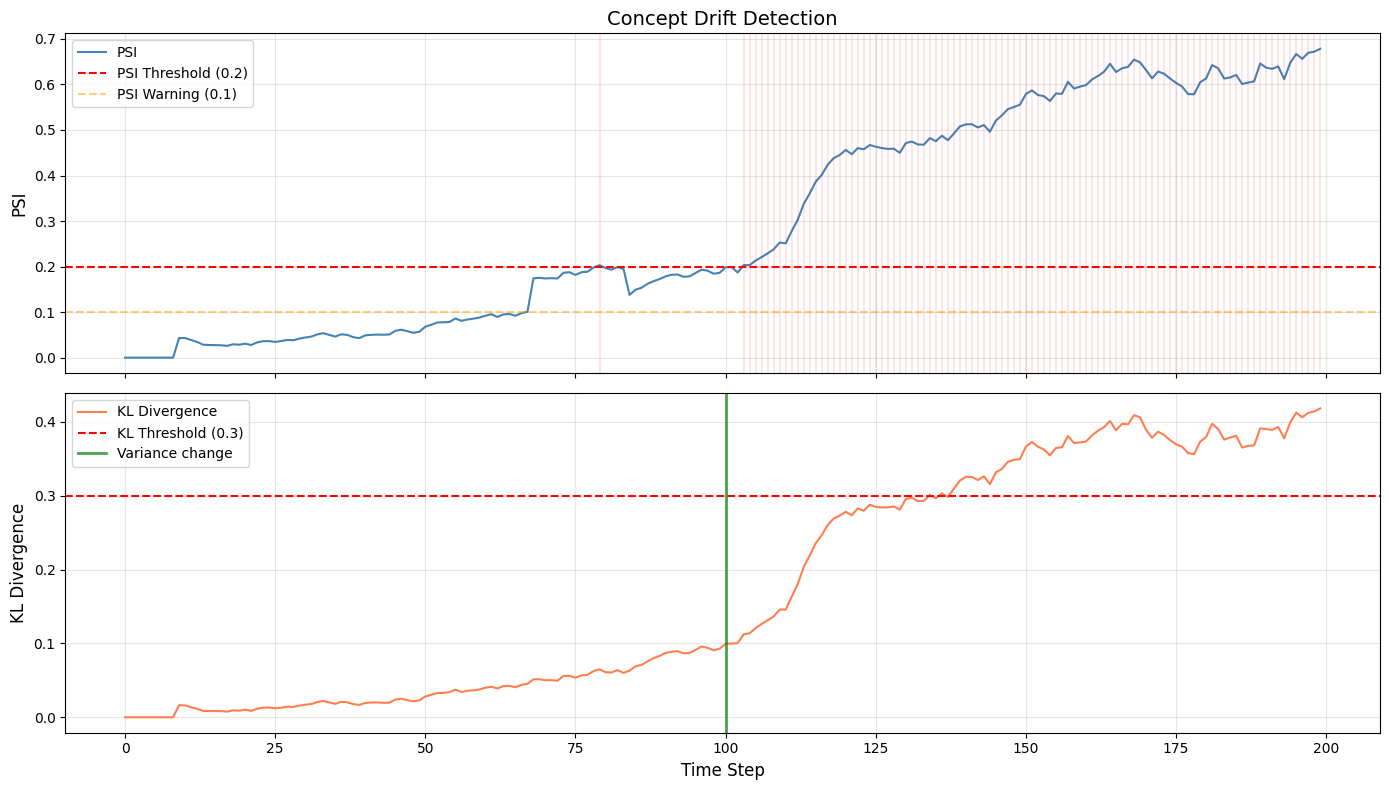

In [7]:
# Visualize drift detection
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(all_psi, color='steelblue', linewidth=1.5, label='PSI')
axes[0].axhline(y=0.2, color='red', linestyle='--', label='PSI Threshold (0.2)')
axes[0].axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='PSI Warning (0.1)')
for dt in drift_times:
    axes[0].axvline(x=dt, color='red', alpha=0.1)
axes[0].set_ylabel('PSI', fontsize=12)
axes[0].set_title('Concept Drift Detection', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_kl, color='coral', linewidth=1.5, label='KL Divergence')
axes[1].axhline(y=0.3, color='red', linestyle='--', label='KL Threshold (0.3)')
axes[1].axvline(x=100, color='green', linestyle='-', alpha=0.7, linewidth=2, label='Variance change')
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('KL Divergence', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Staleness Management

Model **staleness** measures how outdated a serving model is relative to the latest data. Key questions:

- How old is too old? (Depends on the domain — news is hours, e-commerce is days)
- What is the cost of staleness? (Measured in CTR/revenue degradation)
- How to quantify staleness impact?

### Staleness Degradation Model

Empirically, performance degrades approximately as:

$$\text{Quality}(\Delta t) = Q_0 \cdot e^{-\lambda \Delta t}$$

where $\Delta t$ is the staleness (time since last update) and $\lambda$ is the degradation rate.

> **🔑 Pro Tip:** At YouTube, the retrieval model shows ~0.1% CTR degradation per hour of staleness. At this scale, even small percentages translate to millions of dollars. This is why real-time updates are worth the infrastructure investment.

In [8]:
class StalenessManager:
    """Manages model staleness and retraining decisions."""
    
    def __init__(self, max_staleness_hours: float = 24.0,
                 degradation_rate: float = 0.01,  # per hour
                 retrain_threshold: float = 0.02):  # 2% quality drop triggers retrain
        self.max_staleness = max_staleness_hours
        self.degradation_rate = degradation_rate
        self.retrain_threshold = retrain_threshold
        
        self.last_update_time = 0
        self.baseline_quality = 1.0
        self.quality_history = []
    
    def estimate_quality(self, current_time: float) -> float:
        """Estimate current model quality based on staleness."""
        staleness_hours = current_time - self.last_update_time
        degradation = np.exp(-self.degradation_rate * staleness_hours)
        return self.baseline_quality * degradation
    
    def should_retrain(self, current_time: float, observed_quality: Optional[float] = None) -> Dict:
        """Decide whether to retrain."""
        staleness_hours = current_time - self.last_update_time
        estimated_quality = self.estimate_quality(current_time)
        quality_drop = 1.0 - estimated_quality / self.baseline_quality
        
        reasons = []
        should = False
        
        if staleness_hours >= self.max_staleness:
            reasons.append(f"Max staleness exceeded ({staleness_hours:.1f}h >= {self.max_staleness}h)")
            should = True
        
        if quality_drop >= self.retrain_threshold:
            reasons.append(f"Quality degraded by {quality_drop:.1%} (threshold: {self.retrain_threshold:.1%})")
            should = True
        
        if observed_quality is not None:
            observed_drop = 1.0 - observed_quality / self.baseline_quality
            if observed_drop >= self.retrain_threshold:
                reasons.append(f"Observed quality drop: {observed_drop:.1%}")
                should = True
        
        return {
            'should_retrain': should,
            'staleness_hours': staleness_hours,
            'estimated_quality': estimated_quality,
            'quality_drop': quality_drop,
            'reasons': reasons
        }
    
    def record_update(self, current_time: float, quality: float):
        """Record that a model update happened."""
        self.last_update_time = current_time
        self.baseline_quality = quality


# Simulate staleness management over 7 days
manager = StalenessManager(max_staleness_hours=24.0, degradation_rate=0.005)
manager.record_update(0, quality=0.72)  # Initial model with 72% accuracy

hours = np.arange(0, 168, 0.5)  # 7 days, half-hour intervals
qualities = []
retrain_events = []

for h in hours:
    # Add noise to observed quality
    true_quality = manager.estimate_quality(h)
    observed = true_quality + np.random.randn() * 0.005
    qualities.append(observed)
    
    result = manager.should_retrain(h, observed_quality=observed)
    if result['should_retrain']:
        retrain_events.append((h, result['reasons'][0]))
        # Simulate retraining
        new_quality = 0.72 + np.random.randn() * 0.002  # Slight variation
        manager.record_update(h, new_quality)

print(f"Total retrain events over 7 days: {len(retrain_events)}")
for t, reason in retrain_events[:5]:
    print(f"  Hour {t:.0f}: {reason}")

Total retrain events over 7 days: 50
  Hour 4: Observed quality drop: 2.0%
  Hour 4: Observed quality drop: 2.0%
  Hour 9: Quality degraded by 2.2% (threshold: 2.0%)
  Hour 14: Quality degraded by 2.2% (threshold: 2.0%)
  Hour 16: Observed quality drop: 2.0%


## 5. Warm-Starting vs Cold-Starting

When retraining, we must decide whether to:
- **Warm-start**: Initialize from the previous model's weights
- **Cold-start**: Train from random initialization

### When to Warm-Start
- Data distribution hasn't changed drastically
- Model architecture is the same
- Want faster convergence

### When to Cold-Start
- Major distribution shift (e.g., pandemic changed user behavior)
- Architecture change
- Accumulated bias/errors in warm-started model

A common compromise: warm-start embeddings but cold-start the MLP.

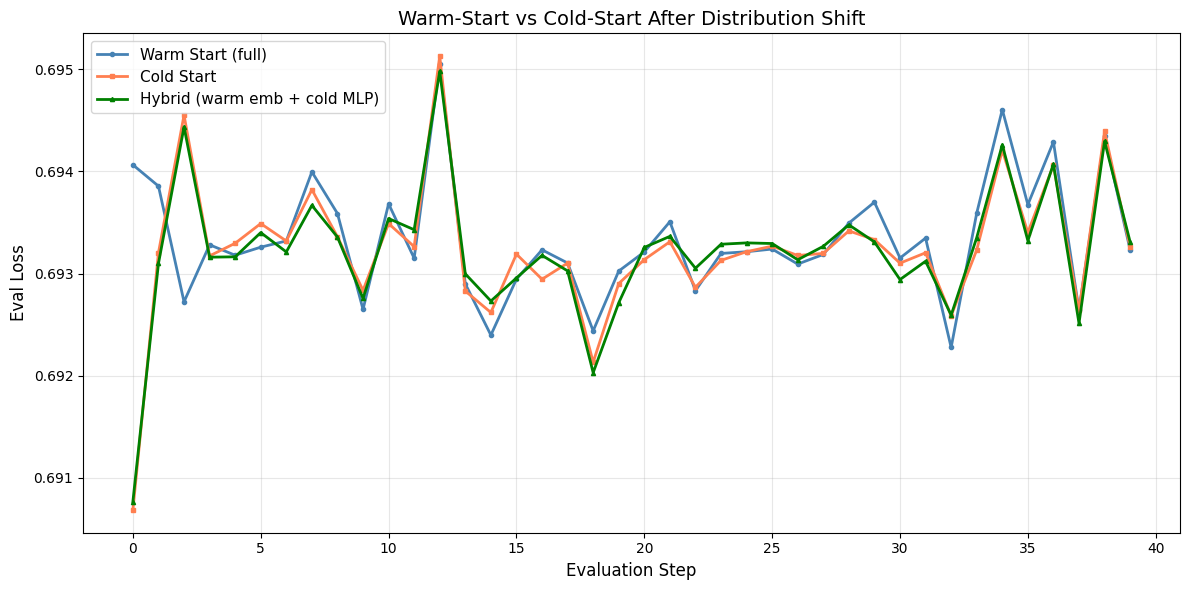

Final losses — Warm: 0.6932, Cold: 0.6933, Hybrid: 0.6933


In [9]:
def compare_warm_cold_start(env, n_pretrain=200, n_finetune=200):
    """Compare warm-start vs cold-start after distribution shift."""
    
    # Phase 1: Pre-train model
    torch.manual_seed(42)
    pretrained = SimpleRecModel(env.num_users, env.num_items)
    optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.001)
    
    for _ in range(n_pretrain):
        env.step()
        batch = env.generate_batch(256)
        logits = pretrained(batch['users'], batch['items'])
        loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Apply large distribution shift
    for _ in range(50):
        env.step()
        # Extra drift
        env.user_factors += np.random.randn(*env.user_factors.shape) * 0.1
    
    # Warm-start: copy pretrained weights
    model_warm = copy.deepcopy(pretrained)
    opt_warm = torch.optim.Adam(model_warm.parameters(), lr=0.001)
    
    # Cold-start: random initialization
    torch.manual_seed(123)
    model_cold = SimpleRecModel(env.num_users, env.num_items)
    opt_cold = torch.optim.Adam(model_cold.parameters(), lr=0.001)
    
    # Hybrid: warm-start embeddings, cold-start MLP
    torch.manual_seed(123)
    model_hybrid = SimpleRecModel(env.num_users, env.num_items)
    model_hybrid.user_emb.weight.data = pretrained.user_emb.weight.data.clone()
    model_hybrid.item_emb.weight.data = pretrained.item_emb.weight.data.clone()
    opt_hybrid = torch.optim.Adam(model_hybrid.parameters(), lr=0.001)
    
    # Phase 2: Fine-tune after shift
    warm_losses, cold_losses, hybrid_losses = [], [], []
    
    for step in range(n_finetune):
        env.step()
        batch = env.generate_batch(256)
        eval_batch = env.generate_batch(512)
        
        for model, opt, losses_list in [
            (model_warm, opt_warm, warm_losses),
            (model_cold, opt_cold, cold_losses),
            (model_hybrid, opt_hybrid, hybrid_losses)
        ]:
            logits = model(batch['users'], batch['items'])
            loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            if step % 5 == 0:
                model.eval()
                with torch.no_grad():
                    eval_logits = model(eval_batch['users'], eval_batch['items'])
                    eval_loss = F.binary_cross_entropy_with_logits(eval_logits, eval_batch['labels'])
                losses_list.append(eval_loss.item())
                model.train()
    
    return warm_losses, cold_losses, hybrid_losses


env2 = NonStationaryEnvironment(num_users=NUM_USERS, num_items=NUM_ITEMS, drift_rate=0.02)
warm_l, cold_l, hybrid_l = compare_warm_cold_start(env2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(warm_l, 'o-', label='Warm Start (full)', color='steelblue', linewidth=2, markersize=3)
ax.plot(cold_l, 's-', label='Cold Start', color='coral', linewidth=2, markersize=3)
ax.plot(hybrid_l, '^-', label='Hybrid (warm emb + cold MLP)', color='green', linewidth=2, markersize=3)
ax.set_xlabel('Evaluation Step', fontsize=12)
ax.set_ylabel('Eval Loss', fontsize=12)
ax.set_title('Warm-Start vs Cold-Start After Distribution Shift', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final losses — Warm: {warm_l[-1]:.4f}, Cold: {cold_l[-1]:.4f}, Hybrid: {hybrid_l[-1]:.4f}")

## 🏋️ Exercise 1: Build an Incremental Learning Pipeline with Drift Detection

Create a complete pipeline that:
1. Trains a model online
2. Monitors for concept drift using PSI
3. Triggers full retraining when drift exceeds threshold
4. Uses warm-starting for normal updates, cold-starting after major drift

In [10]:
# 🏋️ Exercise 1: Incremental learning pipeline

class IncrementalLearningPipeline:
    def __init__(self, num_users: int, num_items: int, emb_dim: int = 16,
                 online_lr: float = 0.001, retrain_lr: float = 0.001,
                 psi_threshold: float = 0.25, retrain_steps: int = 100):
        """
        Complete incremental learning pipeline.
        
        Args:
            num_users, num_items, emb_dim: Model dimensions
            online_lr: LR for online updates
            retrain_lr: LR for full retraining
            psi_threshold: PSI threshold for drift detection
            retrain_steps: Steps for full retraining
        """
        # TODO:
        # 1. Initialize model and optimizer
        # 2. Initialize drift detector
        # 3. Set up data buffer for retraining
        # 4. Initialize tracking metrics
        pass
    
    def process_batch(self, batch: Dict) -> Dict:
        """
        Process one batch of data.
        
        TODO:
        1. Online update the model
        2. Check for drift
        3. If drift detected, trigger full retrain using buffered data
        4. Return metrics
        """
        pass
    
    def full_retrain(self, data_buffer: List[Dict]):
        """
        Full model retraining (warm or cold start based on drift severity).
        """
        # TODO
        pass


# Test:
# env = NonStationaryEnvironment(drift_rate=0.03)
# pipeline = IncrementalLearningPipeline(2000, 5000)
# for t in range(500):
#     env.step()
#     batch = env.generate_batch(256)
#     result = pipeline.process_batch(batch)
#     if t % 100 == 0:
#         print(f"Step {t}: {result}")

## 🏋️ Exercise 2: Implement a Model Freshness Monitor

Build a monitoring system that tracks model freshness metrics and generates alerts.

In [11]:
# 🏋️ Exercise 2: Freshness monitor

class ModelFreshnessMonitor:
    def __init__(self, metric_window: int = 100, 
                 alert_threshold: float = 0.02,
                 staleness_limit_hours: float = 12.0):
        """
        Monitor model freshness and generate alerts.
        
        TODO: Track
        - Rolling accuracy/loss
        - Time since last update
        - Feature distribution shifts
        - Prediction distribution changes
        """
        pass
    
    def log_prediction(self, batch: Dict, predictions: torch.Tensor):
        """Log a batch of predictions for monitoring."""
        # TODO
        pass
    
    def check_health(self) -> Dict:
        """
        Returns health status with alerts if any.
        
        Returns:
            Dict with 'healthy', 'alerts', 'metrics'
        """
        # TODO
        pass


# Test:
# monitor = ModelFreshnessMonitor()
# ... log predictions ...
# health = monitor.check_health()
# print(health)

## 🏋️ Exercise 3: A/B Test Simulator for Online vs Batch Models

Build a simulator that compares an online-updated model against a periodically batch-retrained model.

In [12]:
# 🏋️ Exercise 3: A/B test simulator

class ABTestSimulator:
    def __init__(self, env: NonStationaryEnvironment,
                 batch_retrain_interval: int = 100,
                 batch_retrain_steps: int = 50):
        """
        Simulate an A/B test between online and batch-retrained models.
        
        TODO:
        1. Create two identical initial models
        2. Model A: online updates every step
        3. Model B: batch retraining every `batch_retrain_interval` steps
        4. Track performance metrics for both
        5. Compute statistical significance of differences
        """
        pass
    
    def run(self, n_steps: int = 500) -> Dict:
        """
        Run the A/B test.
        
        Returns:
            Dict with per-step metrics for both models and statistical test results
        """
        # TODO
        pass


# Test:
# env = NonStationaryEnvironment(drift_rate=0.02)
# ab_test = ABTestSimulator(env)
# results = ab_test.run(500)
# print(f"Online wins: {results['online_wins']}")

## Summary

| Topic | Key Takeaway |
|-------|--------------|
| **Online Learning** | Essential for fast-moving domains; use EWC to prevent catastrophic forgetting |
| **Concept Drift** | PSI > 0.25 or significant KL divergence indicates retraining is needed |
| **Staleness** | Quality degrades exponentially; YouTube sees ~0.1% CTR drop per hour |
| **Warm vs Cold Start** | Warm-start for normal updates; consider cold-start after major shifts |
| **Hybrid Strategy** | Warm-start embeddings + cold-start MLP offers the best of both worlds |
| **Production Practice** | Most companies use hybrid: frequent incremental + periodic full retraining |

### Key References
- Kirkpatrick et al., "Overcoming catastrophic forgetting in neural networks" (2017 — EWC)
- He et al., "Real-time Personalization using Embeddings for Search Ranking at Airbnb" (2018)
- Covington et al., "Deep Neural Networks for YouTube Recommendations" (2016, Google)
- Wu et al., "Turning Clocks Back: Time-Aware Recommender Systems" (2022)

### Next Steps
In the next notebook (9.6), we will survey the major training frameworks for recommendation systems including TorchRec, HugeCTR, and DeepRec.